In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import poisson

In [2]:
# Datos extraídos de la Tabla 14 de la tesis de E. Sarango (2025)
data = {
    'Muestra_Video': ['ANALISIS_1', 'ANALISIS_2', 'ANALISIS_3', 'ANALISIS_4', 'ANALISIS_5', 'ANALISIS_6', 'ANALISIS_7'],
    'Vehiculos_Detectados': [135, 60, 33, 116, 120, 132, 38],
    'Tiempo_segundos': [410, 192, 92, 330, 344, 410, 119],
    'Flujo_veh_seg': [0.329, 0.307, 0.337, 0.348, 0.349, 0.280, 0.319],
    'Flujo_veh_min': [19.76, 18.44, 20.26, 20.91, 20.94, 16.84, 19.19]
}

df = pd.DataFrame(data)
df['Tasa_Flujo'] = df['Flujo_veh_seg'] * 3600  # Convertir a vehículos por hora

In [3]:
# Estadísticas descriptivas de las tasas de flujo
print("--- Estadísticas Descriptivas del Flujo Vehicular ---")
resumen_stats = df[['Flujo_veh_seg', 'Flujo_veh_min']].describe()
print(resumen_stats)

# Extraer el valor Lambda (Promedio) para la distribución de Poisson
lambda_min = df['Flujo_veh_min'].mean()
lambda_seg = df['Flujo_veh_seg'].mean()

print(f"\nValor Lambda (λ) para inyección en SUMO: {lambda_min:.2f} veh/min")

--- Estadísticas Descriptivas del Flujo Vehicular ---
       Flujo_veh_seg  Flujo_veh_min
count       7.000000       7.000000
mean        0.324143      19.477143
std         0.024647       1.471878
min         0.280000      16.840000
25%         0.313000      18.815000
50%         0.329000      19.760000
75%         0.342500      20.585000
max         0.349000      20.940000

Valor Lambda (λ) para inyección en SUMO: 19.48 veh/min


C:\Users\Santiago\AppData\Local\Temp\ipykernel_19392\3686950157.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Muestra_Video', y='Flujo_veh_min', data=df, palette='viridis')


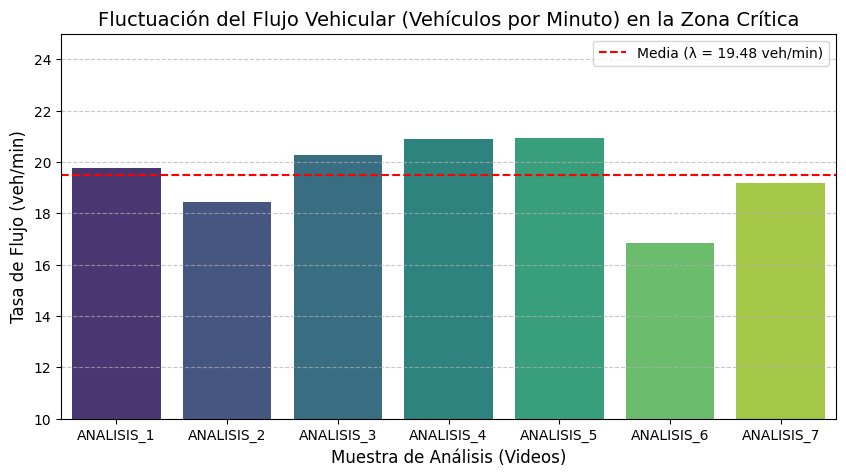

In [4]:
plt.figure(figsize=(10, 5))
sns.barplot(x='Muestra_Video', y='Flujo_veh_min', data=df, palette='viridis')

# Dibujar la línea de la media (Lambda)
plt.axhline(lambda_min, color='red', linestyle='--', label=f'Media (λ = {lambda_min:.2f} veh/min)')

plt.title('Fluctuación del Flujo Vehicular (Vehículos por Minuto) en la Zona Crítica', fontsize=14)
plt.xlabel('Muestra de Análisis (Videos)', fontsize=12)
plt.ylabel('Tasa de Flujo (veh/min)', fontsize=12)
plt.ylim(10, 25)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

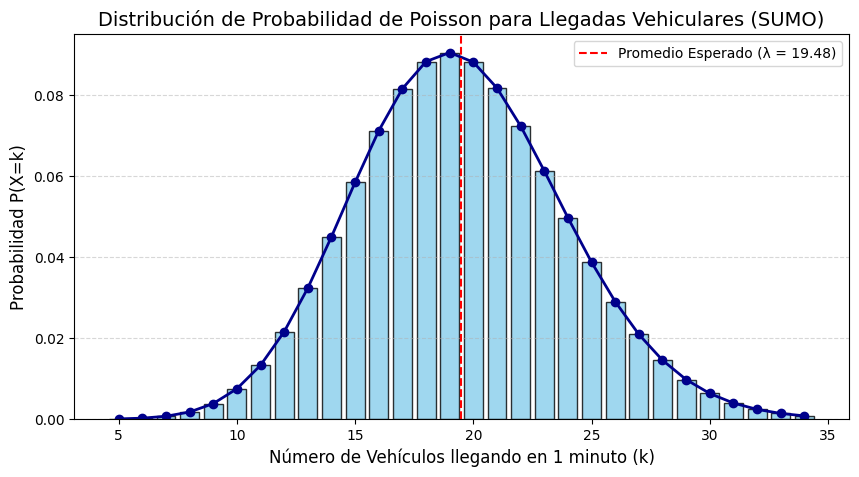

In [5]:
# Crear un rango de posibles llegadas de vehículos en un minuto (ej. de 5 a 35 vehículos)
x = np.arange(5, 35)

# Calcular la Probabilidad de Masa de Función (PMF) de Poisson con nuestro Lambda
poisson_pmf = poisson.pmf(x, mu=lambda_min)

plt.figure(figsize=(10, 5))
plt.bar(x, poisson_pmf, color='skyblue', edgecolor='black', alpha=0.8)
plt.plot(x, poisson_pmf, marker='o', color='darkblue', linestyle='-', linewidth=2)

plt.title('Distribución de Probabilidad de Poisson para Llegadas Vehiculares (SUMO)', fontsize=14)
plt.xlabel('Número de Vehículos llegando en 1 minuto (k)', fontsize=12)
plt.ylabel('Probabilidad P(X=k)', fontsize=12)

# Resaltar la probabilidad máxima (la media)
plt.axvline(lambda_min, color='red', linestyle='--', label=f'Promedio Esperado (λ = {lambda_min:.2f})')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [6]:
# Resumen final del flujo vehicular
resumen_final = pd.DataFrame({
    'Métrica': ['Flujo promedio por segundo', 'Flujo promedio por minuto', 'Flujo promedio por hora'],
    'Valor': [df['Flujo_veh_seg'].mean(), df['Flujo_veh_min'].mean(), df['Flujo_veh_seg'].mean() * 3600],
    'Unidad': ['veh/s', 'veh/min', 'veh/h']
})

print('--- Resumen Final del Flujo Vehicular ---')
display(resumen_final.style.format({'Valor': '{:.3f}'}))

# Velocidad: solo se reporta si existe una columna de velocidad en el conjunto de datos
columnas_velocidad = [col for col in df.columns if 'vel' in col.lower() or 'speed' in col.lower()]
if columnas_velocidad:
    print('\n--- Resumen de Velocidad ---')
    resumen_velocidad = df[columnas_velocidad].mean(numeric_only=True)
    print(resumen_velocidad)
else:
    print('\nNo se encontró una columna de velocidad en los datos actuales. Para calcularla, agrega una columna como Velocidad_km_h o Velocidad_m_s.')

--- Resumen Final del Flujo Vehicular ---


,Métrica,Valor,Unidad
0,Flujo promedio por segundo,0.324,veh/s
1,Flujo promedio por minuto,19.477,veh/min
2,Flujo promedio por hora,1166.914,veh/h



No se encontró una columna de velocidad en los datos actuales. Para calcularla, agrega una columna como Velocidad_km_h o Velocidad_m_s.
